# Imitation BC - Behavioral Cloning via `imitation` library

Trains a policy using the [`imitation`](https://imitation.readthedocs.io/en/latest/algorithms/bc.html) library's BC implementation on human demonstrations for the `OpenElectricKettleLid` task.

Imitation BC minimises the **negative log-probability** of the expert actions under the learner's distribution - a proper maximum likelihood objective when the policy is stochastic.

> **Runtime:** `T4 GPU`

## 1. Setup

In [ ]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else ' No GPU :(')

Fri Apr  3 16:56:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
GITHUB_TOKEN = ''
REPO    = 'sergio-contente/RoboCasa-Project'
BRANCH  = 'b313'
WORKDIR = '/content/RoboCasa-Project'

import os
clone_url = (
    f'https://{GITHUB_TOKEN}@github.com/{REPO}.git'
    if GITHUB_TOKEN else
    f'https://github.com/{REPO}.git'
)

if not os.path.isdir(WORKDIR):
    subprocess.run(
        ['git', 'clone', '--recurse-submodules', '-b', BRANCH, clone_url, WORKDIR],
        check=True
    )
else:
    print(f'{WORKDIR} exists — pulling latest.')
    subprocess.run(['git', '-C', WORKDIR, 'pull'], check=True)
    subprocess.run(
        ['git', '-C', WORKDIR, 'submodule', 'update', '--init', '--recursive'],
        check=True
    )

log = subprocess.run(['git', '-C', WORKDIR, 'log', '--oneline', '-3'],
                     capture_output=True, text=True)
print(log.stdout)

/content/RoboCasa-Project exists — pulling latest.
79959eb ✨
0b0ddaa 🚧  BC
de57827 ✨



In [ ]:
WORKDIR = '/content/RoboCasa-Project'

print('Installing robosuite...')
os.system(f'pip install -e {WORKDIR}/deps/robosuite -q')

print('Installing robocasa...')
os.system(f'pip install -e {WORKDIR}/deps/robocasa -q')

# its eems that imitation 1.0.1 requires stable-baselines3==2.2.1
print('Installing imitation + stable-baselines3...')
os.system('pip install "imitation==1.0.1" "stable-baselines3==2.2.1" -q')

print('Installing pyarrow...')
os.system('pip install pyarrow -q')

# Set up robocasa macros (we override DATASET_BASE_PATH later on)
print('Setting up robocasa macros...')
subprocess.run(
    ['python', '-m', 'robocasa.scripts.setup_macros'],
    input='y\n', text=True, cwd=WORKDIR,
)

# Download kitchen visual assets (textures, meshes) required by the simulator
print('Downloading kitchen assets...')
subprocess.run(
    ['python', '-m', 'robocasa.scripts.download_kitchen_assets'],
    input='y\n', text=True, cwd=WORKDIR,
)

print('Done — restarting kernel...')

Installing robosuite...
Installing robocasa...
Installing imitation + stable-baselines3...
Installing pyarrow...
Setting up robocasa macros...
Done — restarting kernel...


In [ ]:
# Restart kernel so installs are active. Continue from Section 4 after restart.0
#import os; os.kill(os.getpid(), 9)

In [ ]:
WORKDIR      = '/content/RoboCasa-Project'
DATASET_BASE = '/content/datasets'
os.makedirs(DATASET_BASE, exist_ok=True)

# Write DATASET_BASE_PATH into robocasa before first import
import robocasa
with open(os.path.join(robocasa.__path__[0], 'macros_private.py'), 'w') as f:
    f.write(f'DATASET_BASE_PATH = "{DATASET_BASE}"\n')
print(f'DATASET_BASE_PATH = {DATASET_BASE}')

DATASET_PATH = (
    f'{DATASET_BASE}/v1.0/pretrain/atomic/OpenElectricKettleLid/20250820/lerobot'
)

if os.path.isdir(os.path.join(DATASET_PATH, 'data')):
    from pathlib import Path
    n = len(list(Path(DATASET_PATH).glob('data/*/episode_*.parquet')))
    print(f'Dataset already present — {n} episodes found.')
else:
    print('Downloading dataset (pretrain / human, ~200 MB)...')
    result = subprocess.run(
        [
            'python', '-m', 'robocasa.scripts.download_datasets',
            '--tasks',  'OpenElectricKettleLid',
            '--split',  'pretrain',
            '--source', 'human',
        ],
        input='y\n',
        text=True,
        capture_output=False,
        env={**os.environ, 'ROBOCASA_DATASET_BASE_PATH': DATASET_BASE},
    )
    if result.returncode != 0:
        raise RuntimeError('Download failed - check output above.')
    print('Download complete.')

[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /content/RoboCasa-Project/deps/robosuite/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly (e.g. pip install mink==0.0.5), otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


DATASET_BASE_PATH = /content/datasets
Download complete.


In [ ]:
from pathlib import Path
ds = Path(DATASET_PATH)
print('Dataset structure:')
for d in ['data', 'extras', 'meta']:
    print(f'  {d}/  {"✓" if (ds/d).is_dir() else "x missing"}')
episodes = list(ds.glob('data/*/episode_*.parquet'))
print(f'  episodes: {len(episodes)}')
print(f'  modality.json: {"✓" if (ds/"meta"/"modality.json").exists() else "x (bundled fallback OK)"}')

Dataset structure:
  data/  ✓
  extras/  ✓
  meta/  ✓
  episodes: 110
  modality.json: ✓


In [ ]:
import sys
WORKDIR      = '/content/RoboCasa-Project'
DATASET_BASE = '/content/datasets'
OUTPUT_DIR   = f'{WORKDIR}/results'

os.chdir(WORKDIR)
if WORKDIR not in sys.path:
    sys.path.insert(0, WORKDIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

import torch
print(f'Working dir  : {os.getcwd()}')
print(f'Dataset base : {DATASET_BASE}')
print(f'Results dir  : {OUTPUT_DIR}')
print(f'Device       : {"cuda" if torch.cuda.is_available() else "cpu"}')

Working dir  : /content/RoboCasa-Project
Dataset base : /content/datasets
Results dir  : /content/RoboCasa-Project/results
Device       : cuda


In [ ]:
N_DEMO_EPISODES  = 50      # expert episodes to load
N_EPOCHS         = 100     # BC training epochs over the expert data
BATCH_SIZE       = 256     # transitions per gradient step
LEARNING_RATE    = 3e-4    # Adam learning rate
HIDDEN_DIM       = 256     # MLP hidden size (256 matches GAIL / PPO architecture)
ENT_WEIGHT       = 1e-3    # entropy regularisation coefficient (default 1e-3)
L2_WEIGHT        = 0.0     # L2 weight decay on policy parameters
N_EVAL_EPISODES  = 20      # rollout episodes after training

We replay each demo episode in the environment to collect the exact observations our policy will see (gym-wrapper flattened obs), paired with the recorded actions.

In [ ]:
from train_gail import load_expert_trajectories
from gym_wrapper import make_env

print('Initialising environment...')
env = make_env(reward_mode='dense', seed=0)

print(f'Loading {N_DEMO_EPISODES} expert episodes...')
expert_trajs = load_expert_trajectories(
    env,
    n_episodes=N_DEMO_EPISODES,
    dataset_root=Path(DATASET_BASE),
)
env.close()

total_transitions = sum(len(t.acts) for t in expert_trajs)
print(f'\nLoaded {len(expert_trajs)} trajectories — {total_transitions} total transitions')
print(f'Obs dim  : {expert_trajs[0].obs.shape[1]}')
print(f'Act dim  : {expert_trajs[0].acts.shape[1]}')
print(f'Avg ep len: {total_transitions / len(expert_trajs):.0f} steps')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Initialising environment...
Loading 50 expert episodes...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Loaded 50 trajectories — 5146 total transitions
Obs dim  : 136
Act dim  : 12
Avg ep len: 103 steps


## 2. Train with Imitation BC

**Loss:** `neglogp + ent_weight × entropy + l2_weight × L2`  
- `neglogp` - negative log-probability of expert actions under the policy's distribution  
- Entropy bonus (`ent_weight`) keeps the policy from collapsing to deterministic  
- `prob_true_act` in the logs shows how likely the policy considers the expert action (should increase)

In [ ]:
import numpy as np
import torch
from gymnasium import spaces as gym_spaces
from stable_baselines3.common.policies import ActorCriticPolicy
from imitation.algorithms import bc

# Build observation / action spaces (needed for policy init)
_env = make_env(reward_mode='dense', seed=1)
obs_space = _env.observation_space
act_space = _env.action_space
_env.close()

# Build a 256x256 actor-critic policy (same arch as our PPO / GAIL generator)
policy = ActorCriticPolicy(
    observation_space=obs_space,
    action_space=act_space,
    lr_schedule=lambda _: LEARNING_RATE,
    net_arch=[HIDDEN_DIM, HIDDEN_DIM],
)

rng = np.random.default_rng(42)

bc_trainer = bc.BC(
    observation_space=obs_space,
    action_space=act_space,
    demonstrations=expert_trajs,
    rng=rng,
    policy=policy,
    batch_size=BATCH_SIZE,
    optimizer_cls=torch.optim.Adam,
    optimizer_kwargs={'lr': LEARNING_RATE},
    ent_weight=ENT_WEIGHT,
    l2_weight=L2_WEIGHT,
)

print(f'Policy architecture: {[HIDDEN_DIM, HIDDEN_DIM]}')
print(f'Obs dim : {obs_space.shape[0]}')
print(f'Act dim : {act_space.shape[0]}')
print(f'Training for {N_EPOCHS} epochs...')

# Track per-epoch loss for plotting
epoch_losses = []

def _on_epoch_end():
    # imitation logs to its own logger. we capture the last logged loss
    pass

bc_trainer.train(
    n_epochs=N_EPOCHS,
    progress_bar=True,
    log_interval=100,
)

print('\nTraining complete.')

[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


Policy architecture: [256, 256]
Obs dim : 136
Act dim : 12
Training for 100 epochs...


0batch [00:00, ?batch/s]

--------------------------------
| batch_size        | 256      |
| bc/               |          |
|    batch          | 0        |
|    ent_loss       | -0.017   |
|    entropy        | 17       |
|    epoch          | 0        |
|    l2_loss        | 0        |
|    l2_norm        | 785      |
|    loss           | 12.2     |
|    neglogp        | 12.2     |
|    prob_true_act  | 5.26e-06 |
|    samples_so_far | 256      |
--------------------------------


12batch [00:00, 18.53batch/s]
35batch [00:01, 52.15batch/s]
57batch [00:01, 75.72batch/s]
79batch [00:01, 89.56batch/s]
90batch [00:01, 92.88batch/s]
Epoch 4 of 100               

...

--------------------------------
| batch_size        | 256      |
| bc/               |          |
|    batch          | 1800     |
|    ent_loss       | -0.0105  |
|    entropy        | 10.5     |
|    epoch          | 90       |
|    l2_loss        | 0        |
|    l2_norm        | 922      |
|    loss           | 4.55     |
|    neglogp        | 4.56     |
|    prob_true_act  | 0.0105   |
|    samples_so_far | 461056   |
--------------------------------


1810batch [00:17, 105.75batch/s]
1832batch [00:17, 105.87batch/s]
1854batch [00:18, 106.67batch/s]
1877batch [00:18, 107.48batch/s]
1899batch [00:18, 107.77batch/s]
Epoch 94 of 100                 

--------------------------------
| batch_size        | 256      |
| bc/               |          |
|    batch          | 1900     |
|    ent_loss       | -0.0101  |
|    entropy        | 10.1     |
|    epoch          | 95       |
|    l2_loss        | 0        |
|    l2_norm        | 927      |
|    loss           | 4.19     |
|    neglogp        | 4.2      |
|    prob_true_act  | 0.0151   |
|    samples_so_far | 486656   |
--------------------------------


1910batch [00:18, 106.07batch/s]
1932batch [00:18, 105.72batch/s]
1955batch [00:19, 107.45batch/s]
1978batch [00:19, 109.13batch/s]
2000batch [00:19, 106.92batch/s]
2000batch [00:19, 102.78batch/s]


Training complete.


In [ ]:
import json

out = Path(OUTPUT_DIR)

# Save as state dict (loadable with ActorCriticPolicy)
model_path = out / 'imitation_bc_policy.pt'
torch.save({
    'state_dict':  bc_trainer.policy.state_dict(),
    'obs_dim':     obs_space.shape[0],
    'act_dim':     act_space.shape[0],
    'hidden_dim':  HIDDEN_DIM,
    'n_epochs':    N_EPOCHS,
    'batch_size':  BATCH_SIZE,
    'ent_weight':  ENT_WEIGHT,
    'l2_weight':   L2_WEIGHT,
}, model_path)

print(f'Policy saved -> {model_path}')

Policy saved → /content/RoboCasa-Project/results/imitation_bc_policy.pt


## 3. Evaluate

In [ ]:
eval_env = make_env(reward_mode='dense', seed=99)
policy_eval = bc_trainer.policy
policy_eval.set_training_mode(False)

successes, lid_progs, rewards, lengths = [], [], [], []
all_timestep_rewards = []

for ep in range(N_EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False
    ep_r, ep_len = 0.0, 0
    ep_rewards_per_step = []
    info = {}

    while not done:
        action, _ = policy_eval.predict(obs, deterministic=True)
        obs, r, terminated, truncated, info = eval_env.step(action)
        ep_r += float(r)
        ep_len += 1
        ep_rewards_per_step.append(float(r))
        done = terminated or truncated

    successes.append(int(info.get('success', False)))
    lid_progs.append(float(info.get('lid_progress', 0.0)))
    rewards.append(ep_r)
    lengths.append(ep_len)
    all_timestep_rewards.append(ep_rewards_per_step)

eval_env.close()

metrics = {
    'success_rate':       sum(successes) / N_EVAL_EPISODES,
    'avg_lid_progress':   float(np.mean(lid_progs)),
    'std_lid_progress':   float(np.std(lid_progs)),
    'avg_reward':         float(np.mean(rewards)),
    'avg_episode_length': float(np.mean(lengths)),
    'n_episodes':         N_EVAL_EPISODES,
}

(out / 'imitation_bc_eval.json').write_text(json.dumps(metrics, indent=2))

print('Imitation BC Evaluation Results')
print('─' * 38)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'  {k:<28}: {v:.4f}')
    else:
        print(f'  {k:<28}: {v}')

[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


Imitation BC Evaluation Results
──────────────────────────────────────
  success_rate                : 0.0000
  avg_lid_progress            : 0.0000
  std_lid_progress            : 0.0000
  avg_reward                  : 0.0000
  avg_episode_length          : 500.0000
  n_episodes                  : 20


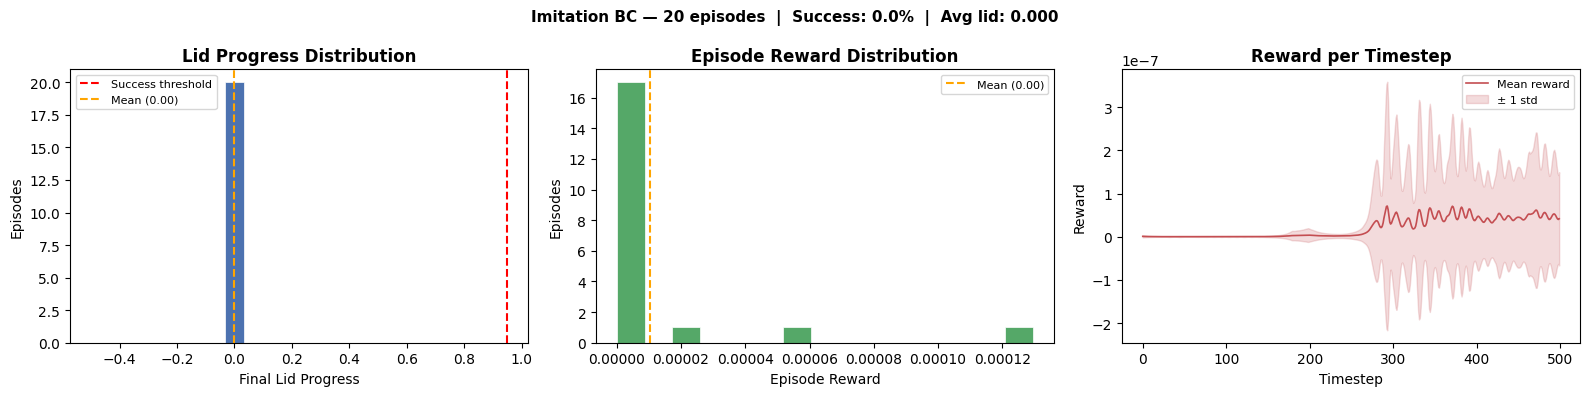

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Lid progress histogram
axes[0].hist(lid_progs, bins=15, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0.95, color='red', linestyle='--', linewidth=1.5, label='Success threshold')
axes[0].axvline(x=float(np.mean(lid_progs)), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({np.mean(lid_progs):.2f})')
axes[0].set_xlabel('Final Lid Progress')
axes[0].set_ylabel('Episodes')
axes[0].set_title('Lid Progress Distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Episode reward histogram
axes[1].hist(rewards, bins=15, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].axvline(x=float(np.mean(rewards)), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({np.mean(rewards):.2f})')
axes[1].set_xlabel('Episode Reward')
axes[1].set_ylabel('Episodes')
axes[1].set_title('Episode Reward Distribution', fontweight='bold')
axes[1].legend(fontsize=8)

# Reward per timestep curve
max_len = max(len(ep) for ep in all_timestep_rewards)
padded = np.full((len(all_timestep_rewards), max_len), np.nan)
for i, ep in enumerate(all_timestep_rewards):
    padded[i, :len(ep)] = ep

mean_r = np.nanmean(padded, axis=0)
std_r  = np.nanstd(padded, axis=0)
steps  = np.arange(max_len)

axes[2].plot(steps, mean_r, color='#C44E52', linewidth=1.2, label='Mean reward')
axes[2].fill_between(steps, mean_r - std_r, mean_r + std_r,
                     color='#C44E52', alpha=0.2, label='± 1 std')
axes[2].set_xlabel('Timestep')
axes[2].set_ylabel('Reward')
axes[2].set_title('Reward per Timestep', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle(
    f'Imitation BC — {N_EVAL_EPISODES} episodes  |  '
    f'Success: {metrics["success_rate"]*100:.1f}%  |  '
    f'Avg lid: {metrics["avg_lid_progress"]:.3f}',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.savefig(out / 'imitation_bc_eval_plot.png', dpi=150)
plt.show()

In [ ]:
SAVE_TO_DRIVE = True
DRIVE_FOLDER  = 'MyDrive/RoboCasa'

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    import shutil
    dest = f'/content/drive/{DRIVE_FOLDER}'
    os.makedirs(dest, exist_ok=True)

    for fname in [
        'imitation_bc_policy.pt',
        'imitation_bc_eval.json',
        'imitation_bc_eval_plot.png',
    ]:
        src = out / fname
        if src.exists():
            shutil.copy(src, dest)
            print(f'Copied {fname} → {dest}')
else:
    print('Drive save skipped (set SAVE_TO_DRIVE = True).')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied imitation_bc_policy.pt → /content/drive/MyDrive/RoboCasa
Copied imitation_bc_eval.json → /content/drive/MyDrive/RoboCasa
Copied imitation_bc_eval_plot.png → /content/drive/MyDrive/RoboCasa


### How to reload the policy
```python
import torch
from stable_baselines3.common.policies import ActorCriticPolicy
from gym_wrapper import make_env

env = make_env(reward_mode='dense', seed=0)
ckpt = torch.load('results/imitation_bc_policy.pt', map_location='cpu')

policy = ActorCriticPolicy(
    observation_space=env.observation_space,
    action_space=env.action_space,
    lr_schedule=lambda _: 3e-4,
    net_arch=[ckpt['hidden_dim'], ckpt['hidden_dim']],
)
policy.load_state_dict(ckpt['state_dict'])
policy.set_training_mode(False)

obs, _ = env.reset()
action, _ = policy.predict(obs, deterministic=True)
```